2×2 Matrix{Float64}:
 0.0873823  0.9634
 0.0912525  0.963876

2×2 Matrix{Float64}:
 0.427959  0.960634
 0.431172  0.965687

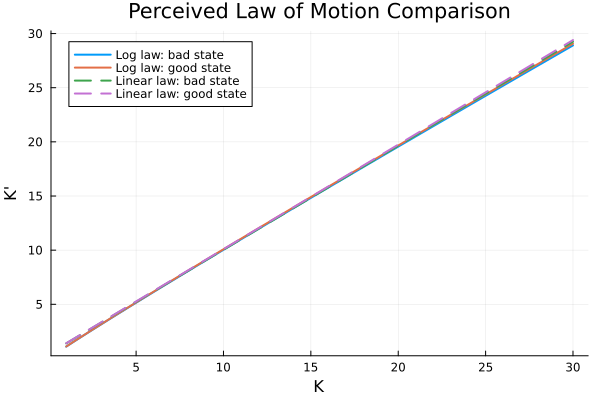

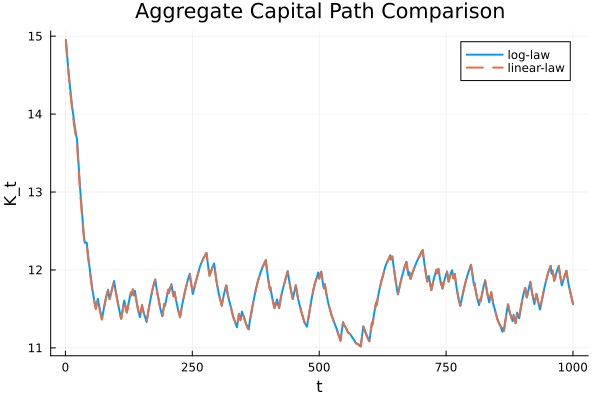

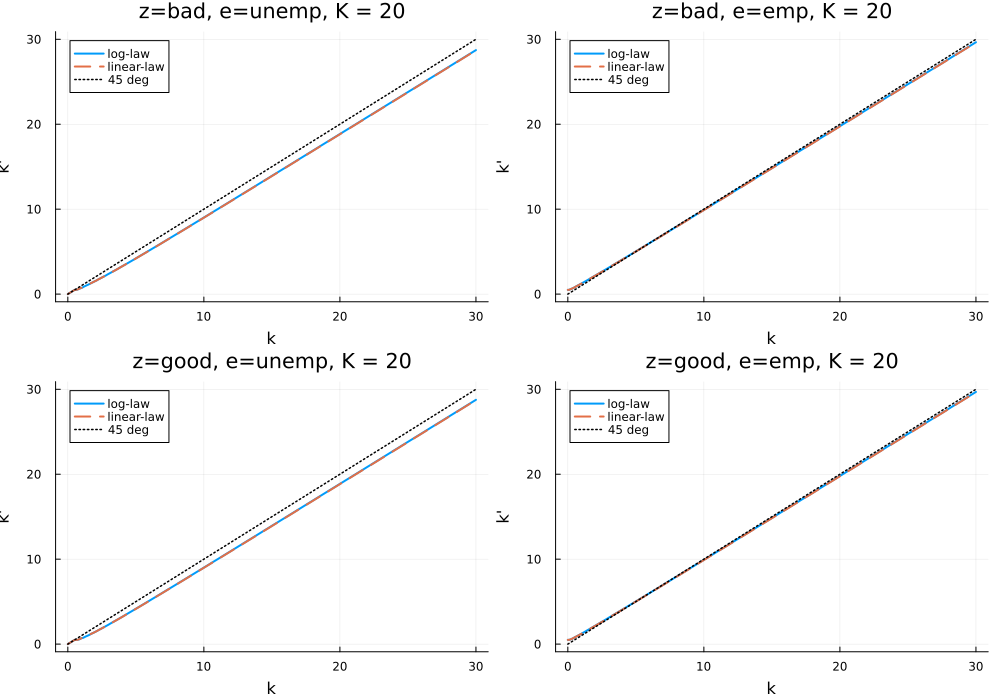

Comparison of solved perceived laws of motion

[Log-law notebook]
law_type = log
coeff = 
R2 by state = [0.9997917569331751, 0.9998994172155053]

[Linear-law notebook]
law_type = linear
coeff = 
R2 by state = [0.9997934264437218, 0.9998985866157637]

Summary table
Law          | a_bad        | b_bad        | a_good       | b_good      
log          | 0.087382     | 0.963400     | 0.091253     | 0.963876    
linear       | 0.427959     | 0.960634     | 0.431172     | 0.965687    

Law          | R2_bad       | R2_good     
log          | 0.999792     | 0.999899    
linear       | 0.999793     | 0.999899    

Comparison of simulated aggregate capital paths
Law          | mean(K)      | std(K)       | min(K)       | max(K)      
log          | 11.708787    | 0.352376     | 10.975888    | 14.949833   
linear       | 11.707554    | 0.350687     | 10.971209    | 14.949833   


In [7]:
# Compare results of two perceived laws of motion:
#=
Log version: log K' = a_z + b_z log K
Estimated parameters:
bad state : a = 0.0874, b = 0.9634, R^2 = 0.999792
good state: a = 0.0913, b = 0.9639, R^2 = 0.999899

Linear version: K' = a_z + b_z K
Estimated parameters:
bad state : a = 0.4280, b = 0.9606, R^2 = 0.999793
good state: a = 0.4312, b = 0.9657, R^2 = 0.999899
=#

include(raw"C:\Users\30945\Desktop\Yuxuan ZHAO\minnesota\PhD_first_year\ECON8107\KS1998\src\KSFunctions.jl")
using .KSFunctions
using Serialization, Printf, Statistics, Plots

const KSParams = KSFunctions.KSParams


# =========================================================
# 0) Load saved results
# =========================================================
log_path = raw"C:\Users\30945\Desktop\Yuxuan ZHAO\minnesota\PhD_first_year\ECON8107\KS1998\notebooks\ks_log_result.jls"
lin_path = raw"C:\Users\30945\Desktop\Yuxuan ZHAO\minnesota\PhD_first_year\ECON8107\KS1998\notebooks\ks_linear_result.jls"

log_bundle = deserialize(log_path)
lin_bundle = deserialize(lin_path)

log_res = log_bundle["res"]
lin_res = lin_bundle["res"]

log_par = log_bundle["par"]
lin_par = lin_bundle["par"]

log_coeff = log_bundle["coeff_star"]
lin_coeff = lin_bundle["coeff_star"]

log_kgrid = log_bundle["kgrid"]
lin_kgrid = lin_bundle["kgrid"]

log_Kgrid = log_bundle["Kgrid"]
lin_Kgrid = lin_bundle["Kgrid"]

log_pol = log_bundle["pol_star"]
lin_pol = lin_bundle["pol_star"]

log_K_series = log_bundle["K_series_final"]
lin_K_series = lin_bundle["K_series_final"]

log_z_path = log_bundle["z_path_final"]
lin_z_path = lin_bundle["z_path_final"]

# =========================================================
# 1) Compare solved results
# =========================================================
println("===================================================")
println("Comparison of solved perceived laws of motion")
println("===================================================")

println("\n[Log-law notebook]")
println("law_type = ", log_bundle["law_type"])
println("coeff = ")
display(log_coeff)
println("R2 by state = ", log_res.r2)

println("\n[Linear-law notebook]")
println("law_type = ", lin_bundle["law_type"])
println("coeff = ")
display(lin_coeff)
println("R2 by state = ", lin_res.r2)

println("\nSummary table")
@printf("%-12s | %-12s | %-12s | %-12s | %-12s\n", "Law", "a_bad", "b_bad", "a_good", "b_good")
@printf("%-12s | %-12.6f | %-12.6f | %-12.6f | %-12.6f\n",
        "log", log_coeff[1,1], log_coeff[1,2], log_coeff[2,1], log_coeff[2,2])
@printf("%-12s | %-12.6f | %-12.6f | %-12.6f | %-12.6f\n",
        "linear", lin_coeff[1,1], lin_coeff[1,2], lin_coeff[2,1], lin_coeff[2,2])

@printf("\n%-12s | %-12s | %-12s\n", "Law", "R2_bad", "R2_good")
@printf("%-12s | %-12.6f | %-12.6f\n", "log", log_res.r2[1], log_res.r2[2])
@printf("%-12s | %-12.6f | %-12.6f\n", "linear", lin_res.r2[1], lin_res.r2[2])


# =========================================================
# 2) Compare implied law of motion curves
# =========================================================
K_range = collect(range(1.0, 30.0, length = 300))

Kprime_log_bad = exp.(log_coeff[1,1] .+ log_coeff[1,2] .* log.(K_range))
Kprime_log_good = exp.(log_coeff[2,1] .+ log_coeff[2,2] .* log.(K_range))

Kprime_lin_bad = lin_coeff[1,1] .+ lin_coeff[1,2] .* K_range
Kprime_lin_good = lin_coeff[2,1] .+ lin_coeff[2,2] .* K_range

pLaw = plot(K_range, Kprime_log_bad, lw=2, label="Log law: bad state",
            xlabel="K", ylabel="K'", title="Perceived Law of Motion Comparison")
plot!(pLaw, K_range, Kprime_log_good, lw=2, label="Log law: good state")
plot!(pLaw, K_range, Kprime_lin_bad, lw=2, ls=:dash, label="Linear law: bad state")
plot!(pLaw, K_range, Kprime_lin_good, lw=2, ls=:dash, label="Linear law: good state")
display(pLaw)

# =========================================================
# 3) Compare simulated aggregate K_t paths
# =========================================================
println("\n===================================================")
println("Comparison of simulated aggregate capital paths")
println("===================================================")

@printf("%-12s | %-12s | %-12s | %-12s | %-12s\n", "Law", "mean(K)", "std(K)", "min(K)", "max(K)")
@printf("%-12s | %-12.6f | %-12.6f | %-12.6f | %-12.6f\n",
        "log", mean(log_K_series), std(log_K_series), minimum(log_K_series), maximum(log_K_series))
@printf("%-12s | %-12.6f | %-12.6f | %-12.6f | %-12.6f\n",
        "linear", mean(lin_K_series), std(lin_K_series), minimum(lin_K_series), maximum(lin_K_series))

Tplot = min(1000, min(length(log_K_series), length(lin_K_series)))
tt = 1:Tplot

pK = plot(tt, log_K_series[tt], lw=2, label="log-law",
          xlabel="t", ylabel="K_t", title="Aggregate Capital Path Comparison")
plot!(pK, tt, lin_K_series[tt], lw=2, ls=:dash, label="linear-law")
display(pK)

# =========================================================
# 4) Compare policy functions at K = 20
# =========================================================
function nearest_index_local(grid::Vector{Float64}, x::Float64)
    j = searchsortedfirst(grid, x)
    if j <= 1
        return 1
    elseif j > length(grid)
        return length(grid)
    else
        return abs(grid[j] - x) < abs(grid[j - 1] - x) ? j : j - 1
    end
end

K_fixed = 20.0
iK_log = nearest_index_local(log_Kgrid, K_fixed)
iK_lin = nearest_index_local(lin_Kgrid, K_fixed)

state_titles = Dict(
    (1,1) => "z=bad, e=unemp",
    (1,2) => "z=bad, e=emp",
    (2,1) => "z=good, e=unemp",
    (2,2) => "z=good, e=emp"
)

pPol = plot(layout=(2,2), size=(1000,700), legend=:topleft)

panel = 1
for iz in 1:2
    for ie in 1:2
        kp_log = vec(log_pol[:, iK_log, ie, iz])
        kp_lin = vec(lin_pol[:, iK_lin, ie, iz])

        plot!(pPol[panel], log_kgrid, kp_log, lw=2, label="log-law")
        plot!(pPol[panel], lin_kgrid, kp_lin, lw=2, ls=:dash, label="linear-law")
        plot!(pPol[panel], log_kgrid, log_kgrid, lw=1.5, ls=:dot, color=:black, label="45 deg")

        xlabel!(pPol[panel], "k")
        ylabel!(pPol[panel], "k'")
        title!(pPol[panel], "$(state_titles[(iz,ie)]), K = 20")
        panel += 1
    end
end

display(pPol)
